In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import numpy as np

1. Model settings

In [2]:
YEAR = 2019

File_dir= Path.cwd() 

BASE_PATH = "data"
DENMARK_PATH = f"{BASE_PATH}/Denmark_En_DH"
LOAD_PATH = f"{BASE_PATH}/Load/time_series_60min_singleindex.csv"

def annualize(capex, r, lifetime):
    crf = (r * (1 + r)**lifetime) / ((1 + r)**lifetime - 1)
    return capex * crf

r = 0.07

# Cost assumptions 
CAPITAL_COST_SOLAR = float(annualize(772_000,   r, lifetime=25))
CAPITAL_COST_WIND_ON = float(annualize(1_950_000, r, lifetime=25))
CAPITAL_COST_WIND_OFF = float(annualize(2_900_000, r, lifetime=25))
CAPITAL_COST_GAS = float(annualize(1_300_000, r, lifetime=25))

MARGINAL_COST_SOLAR = 0
MARGINAL_COST_WIND_ON = 0
MARGINAL_COST_WIND_OFF = 0
MARGINAL_COST_GAS = 43.18 / 0.47    


explanation for us: This block defines the main settings of the model. First, we have selected the year of data that will be used in the simulation. The next lines define the file paths to access the input datasets: the folder containing the renewable generation data for Ireland and the file containing the electricity demand time series.

The last part defines the cost assumptions for the generation technologies (solar, wind, and gas). These include capital costs, which represent the annualized investment needed to build generation capacity, and marginal costs, which represent the cost of producing electricity.

2. Read input data

In [3]:
#solar, wind, and electricity demand datasets are read from the CSV files
pv = pd.read_csv(
    f"{DENMARK_PATH}/ninja-pv-country-DK-national-merra2.csv",
    skiprows=3
)
# IMPORTANT: skiprows=3 is used to skip the first three rows of the CSV file, which may contain metadata or headers that are not part of the actual data. This ensures that the DataFrame is correctly structured with the appropriate columns and data types.
wind_on = pd.read_csv(
    f"{DENMARK_PATH}/ninja-wind-country-DK-current_onshore-merra2.csv",
    skiprows=3
)
wind_off = pd.read_csv(
    f"{DENMARK_PATH}/ninja-wind-country-DK-current_offshore-merra2.csv",
    skiprows=3
)
load_df = pd.read_csv(LOAD_PATH)

# Parse timestamps as UTC-aware, 
pv["time"] = pd.to_datetime(pv["time"], utc=True)
wind_on["time"] = pd.to_datetime(wind_on["time"], utc=True)
wind_off["time"] = pd.to_datetime(wind_off["time"], utc=True)
load_df["utc_timestamp"] = pd.to_datetime(load_df["utc_timestamp"], utc=True)

# Set index
pv = pv.set_index("time")
wind_on = wind_on.set_index("time")
wind_off = wind_off.set_index("time")
load_df = load_df.set_index("utc_timestamp")

# Convert all indices to timezone-naive
pv.index = pv.index.tz_convert(None)
wind_on.index = wind_on.index.tz_convert(None)
wind_off.index = wind_off.index.tz_convert(None)
load_df.index = load_df.index.tz_convert(None)

# Keep only the year WE want
pv = pv.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_on = wind_on.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_off = wind_off.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
load_df = load_df.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]

#IPORTAT: the timestamp columns are converted into proper datetime objects using pd.to_datetime, initially treating them as UTC timestamps. These timestamps are then set as the index of each dataset so that the data can be handled as time series. After that, the timezone information is removed because PyPSA requires timestamps without timezone information. 
#FOR THIS PART I USED CHAT GPT BECAUSE AT THE BEGGINING I HAD ERROR OR EMPTY INFORMATION SO I COULD NOT UNDERSTAND WHAT WAS GOING ON.

# Build snapshots:set of hourly timestamps are set of hourly timestamps created for the entire year, representing the time resolution that the model will use
snapshots = pd.date_range(
    start=f"{YEAR}-01-01 00:00:00",
    end=f"{YEAR}-12-31 23:00:00",
    freq="h"
)

# A new dataframe is created with the snapshots above. we are adding 3 key variables.The renewable variables represents the capacity factors(the fraction of installed capacity that can produce electricity at each hour).
data = pd.DataFrame(index=snapshots)
data["load"] = load_df["IE_load_actual_entsoe_transparency"] #electricity demand
data["solar_cf"] = pv["NATIONAL"] #solar availability
data["wind_on_cf"] = wind_on["NATIONAL"]
data["wind_off_cf"] = wind_off["NATIONAL"]#wind availability

# Reindex explicitly to snapshots and fill any small gaps(data is reindexed to exactly match the snapshot timeline, and any small missing values are filled using interpolation and forward/backward filling.)
data = data.reindex(snapshots)
data = data.interpolate(method="time").ffill().bfill()

print(data.isna().sum())
print(data.head())
print(data.tail())
#the print part is just to check that there is no missing values and how the code is working...

load           0
solar_cf       0
wind_on_cf     0
wind_off_cf    0
dtype: int64
                       load  solar_cf  wind_on_cf  wind_off_cf
2019-01-01 00:00:00  2980.0       0.0    0.805840     0.896970
2019-01-01 01:00:00  2823.0       0.0    0.839171     0.916942
2019-01-01 02:00:00  2595.0       0.0    0.861352     0.927392
2019-01-01 03:00:00  2456.0       0.0    0.882439     0.948853
2019-01-01 04:00:00  2376.0       0.0    0.903024     0.960074
                       load  solar_cf  wind_on_cf  wind_off_cf
2019-12-31 19:00:00  3852.0       0.0    0.277339     0.337167
2019-12-31 20:00:00  3580.0       0.0    0.254643     0.306219
2019-12-31 21:00:00  3351.0       0.0    0.259271     0.300596
2019-12-31 22:00:00  3133.0       0.0    0.288256     0.330148
2019-12-31 23:00:00  3096.0       0.0    0.319425     0.372246


3. Build the PyPSA network

In [4]:
n = pypsa.Network() # thiscreates a new PyPSA network object. This object represents the electricity system that we will analyze.
n.set_snapshots(snapshots) #we are setting the time resolution of the model.

n.add("Bus", "Denmark") #we are creating the bus, wich in this model represents a node where electricity flows are balanced. 

n.add(
    "Load",
    "demand",
    bus="Denmark",
    p_set=data["load"].values
)# we are adding the electricity demand to the bus. The p_set parameter specifies the time series of electricity demand that we want to meet at each snapshot.

n.add(
    "Generator",
    "solar",
    bus="Denmark",
    carrier="solar",
    p_max_pu=data["solar_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_SOLAR,
    marginal_cost=MARGINAL_COST_SOLAR
)

n.add(
    "Generator",
    "wind_onshore",
    bus="Denmark",
    carrier="wind_onshore",
    p_max_pu=data["wind_on_cf"].values,
    p_nom_extendable=True,
    capital_cost= CAPITAL_COST_WIND_ON,
    marginal_cost=MARGINAL_COST_WIND_ON
)

n.add(
    "Generator",
    "wind_offshore",
    bus="Denmark",
    carrier="wind_offshore",
    p_max_pu=data["wind_off_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_WIND_OFF,
    marginal_cost=MARGINAL_COST_WIND_OFF
)
n.add(
    "Generator",
    "gas",
    bus="Denmark",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_GAS,
    marginal_cost=MARGINAL_COST_GAS
)
# After defining the demand, we add three generation technologies to the system: solar, wind, and gas. All generators are connected to the Ireland bus. For solar and wind, the parameter p_max_pu uses the hourly capacity factors from the dataset, which represent how much of the installed capacity can generate electricity at each hour depending on weather conditions.
#The parameter p_nom_extendable=True allows the model to decide how much capacity to install for each technology during the optimization. Instead of fixing the generation capacity beforehand, the model determines the cost-optimal capacities based on the demand and the cost assumptions.

n.generators #prints the table of generators in the network 

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
solar,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_onshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_offshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
gas,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


4. Optimise the system

In [5]:
n.optimize(solver_name="gurobi") # here we run the optimization of the electricity system model in PyPSA. During this step, the model calculates the cost-optimal solution for the system while ensuring that electricity demand is met at every hour of the year.

C:\Users\raula\AppData\Local\Temp\ipykernel_32956\2402434390.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="gurobi") # here we run the optimization of the electricity system model in PyPSA. During this step, the model calculates the cost-optimal solution for the system while ensuring that electricity demand is met at every hour of the year.
Index(['Denmark'], dtype='str', name='name')
Index(['solar', 'wind_onshore', 'wind_offshore', 'gas'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 248.01it/s]
INFO:linopy.io: Writing time: 0.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2785388


INFO:gurobipy:Set parameter LicenseID to value 2785388


...

Solved in 8440 iterations and 0.95 seconds (0.50 work units)


INFO:gurobipy:Solved in 8440 iterations and 0.95 seconds (0.50 work units)


Optimal objective  2.863533616e+09


INFO:gurobipy:Optimal objective  2.863533616e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78844 duals
Objective: 2.86e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

# Part (c): Denmark storage impact on the system

In [6]:
# ============================================
# PART C: Main grid model with storage
# ============================================

nf = pypsa.Network() # thiscreates a new PyPSA network object. This object represents the electricity system that we will analyze.
nf.set_snapshots(snapshots) #we are setting the time resolution of the model.

nf.add("Bus", "Denmark") #we are creating the bus, wich in this model represents a node where electricity flows are balanced. 

nf.add(
    "Load",
    "demand",
    bus="Denmark",
    p_set=data["load"].values
)# we are adding the electricity demand to the bus. The p_set parameter specifies the time series of electricity demand that we want to meet at each snapshot.

nf.add(
    "Generator",
    "solar",
    bus="Denmark",
    carrier="solar",
    p_max_pu=data["solar_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_SOLAR,
    marginal_cost=MARGINAL_COST_SOLAR
)

nf.add(
    "Generator",
    "wind_onshore",
    bus="Denmark",
    carrier="wind_onshore",
    p_max_pu=data["wind_on_cf"].values,
    p_nom_extendable=True,
    capital_cost= CAPITAL_COST_WIND_ON,
    marginal_cost=MARGINAL_COST_WIND_ON
)

nf.add(
    "Generator",
    "wind_offshore",
    bus="Denmark",
    carrier="wind_offshore",
    p_max_pu=data["wind_off_cf"].values,
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_WIND_OFF,
    marginal_cost=MARGINAL_COST_WIND_OFF
)
nf.add(
    "Generator",
    "gas",
    bus="Denmark",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=CAPITAL_COST_GAS,
    marginal_cost=MARGINAL_COST_GAS
)
# After defining the demand, we add three generation technologies to the system: solar, wind, and gas. All generators are connected to the Ireland bus. For solar and wind, the parameter p_max_pu uses the hourly capacity factors from the dataset, which represent how much of the installed capacity can generate electricity at each hour depending on weather conditions.
#The parameter p_nom_extendable=True allows the model to decide how much capacity to install for each technology during the optimization. Instead of fixing the generation capacity beforehand, the model determines the cost-optimal capacities based on the demand and the cost assumptions.

nf.generators #prints the table of generators in the network

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
solar,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_onshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
wind_offshore,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
gas,Denmark,PQ,,0.0,0.0,True,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


In [7]:

CAPITAL_COST_BATTERY    = float(annualize(183_000 * 6, r, lifetime=20))  # €/MWh × 6h → €/MW

CAPITAL_COST_ELECTROLYZER = float(annualize(840_000, r, lifetime=40))    # €/MW
CAPITAL_COST_H2_STORAGE   = float(annualize(6_010,  r, lifetime=20))    # €/MWh
CAPITAL_COST_FUEL_CELL = float(annualize(1_591_578, r, lifetime=30))              # €/MW

# --- Li-ion Battery ---
nf.add("StorageUnit",
    name="battery",
    bus="Denmark",
    carrier="battery",
    p_nom_extendable=True,
    max_hours=6,
    efficiency_store=0.93,
    efficiency_dispatch=0.93,
    standing_loss=0.00001,
    capital_cost=CAPITAL_COST_BATTERY
)

# --- H2 (Power-to-Gas) ---
nf.add("Bus", "H2", carrier="H2")

nf.add("Link",
    name="electrolyzer",
    bus0="Denmark",
    bus1="H2",
    carrier="H2",
    p_nom_extendable=True,
    efficiency=0.73,
    capital_cost=CAPITAL_COST_ELECTROLYZER
)

nf.add("Store",
    name="H2_storage",
    bus="H2",
    carrier="H2",
    e_nom_extendable=True,
    capital_cost=CAPITAL_COST_H2_STORAGE,
    standing_loss=0.0
)

nf.add("Link",
    name="fuel_cell",
    bus0="H2",
    bus1="Denmark",
    carrier="H2",
    p_nom_extendable=True,
    efficiency=0.58,
    capital_cost=CAPITAL_COST_FUEL_CELL
)

# --- Optimize ---
nf.optimize(solver_name="gurobi")


C:\Users\raula\AppData\Local\Temp\ipykernel_32956\445048335.py:53: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  nf.optimize(solver_name="gurobi")
Index(['Denmark', 'H2'], dtype='str', name='name')
Index(['solar', 'wind_onshore', 'wind_offshore', 'gas'], dtype='str', name='name')
Index(['electrolyzer', 'fuel_cell'], dtype='str', name='name')
Index(['H2_storage'], dtype='str', name='name')
Index(['battery'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 263.62it/s]
INFO:linopy.io: Writing time: 0.25s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2785388


INFO:gurobipy:Set parameter LicenseID to value 2785388


...

Solved in 29015 iterations and 3.98 seconds (2.84 work units)


INFO:gurobipy:Solved in 29015 iterations and 3.98 seconds (2.84 work units)


Optimal objective  2.817013177e+09


INFO:gurobipy:Optimal objective  2.817013177e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96368 primals, 210248 duals
Objective: 2.82e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

In [8]:
# --- Results: installed capacities ---
print("=== GENERATORS (part a) ===")
print(n.generators[["p_nom_opt"]])

# --- Results: Annual Generation in TWh ---
print("\n=== ANNUAL GENERATION (part a) [TWh] ===")
# Calculamos en MWh y dividimos por 1,000,000 para obtener TWh
annual_generation_twh = (n.generators_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()) / 1e6
print(annual_generation_twh)

=== GENERATORS (part a) ===
                 p_nom_opt
name                      
solar          3816.200772
wind_onshore   5160.275008
wind_offshore     0.000000
gas            4365.366412

=== ANNUAL GENERATION (part a) [TWh] ===
name
solar             3.767529
wind_onshore     11.579450
wind_offshore     0.000000
gas              13.717758
dtype: float64


=== GENERATORS (part c) ===
                 p_nom_opt
name                      
solar          5161.244340
wind_onshore   5269.952595
wind_offshore     0.000000
gas            3298.058608

=== ANNUAL GENERATION (part c) [TWh] ===
name
solar             4.601699
wind_onshore     12.422813
wind_offshore     0.000000
gas              12.137285
dtype: float64

=== BATTERY ===
           p_nom_opt
name                
battery  1064.106205

=== HYDROGEN - POWER ===
              p_nom_opt
name                   
electrolyzer        0.0
fuel_cell           0.0

=== HYDROGEN - ENERGY ===
            e_nom_opt
name                 
H2_storage        0.0


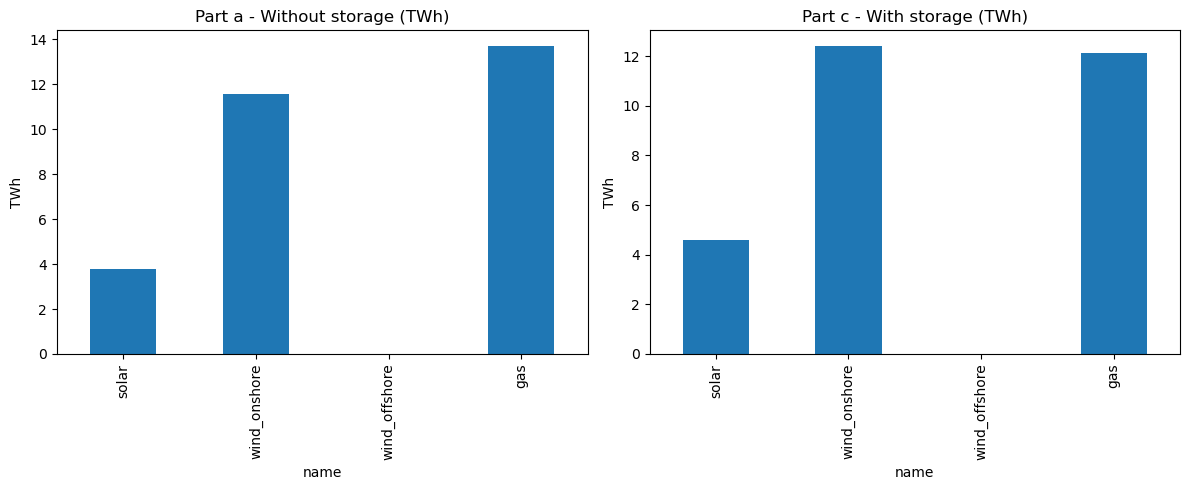

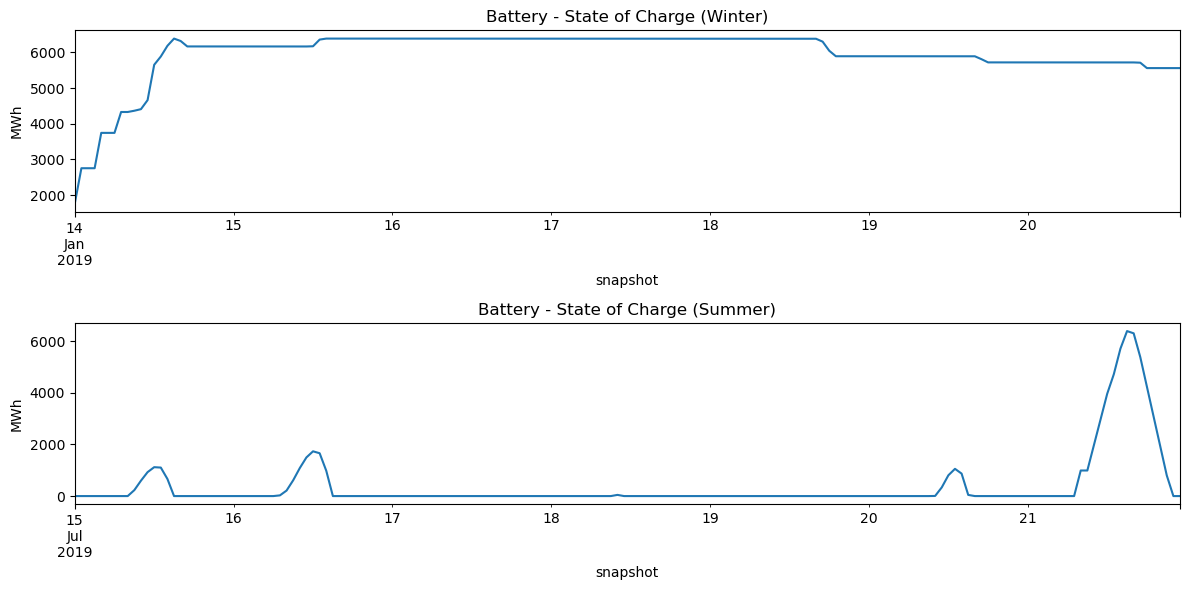

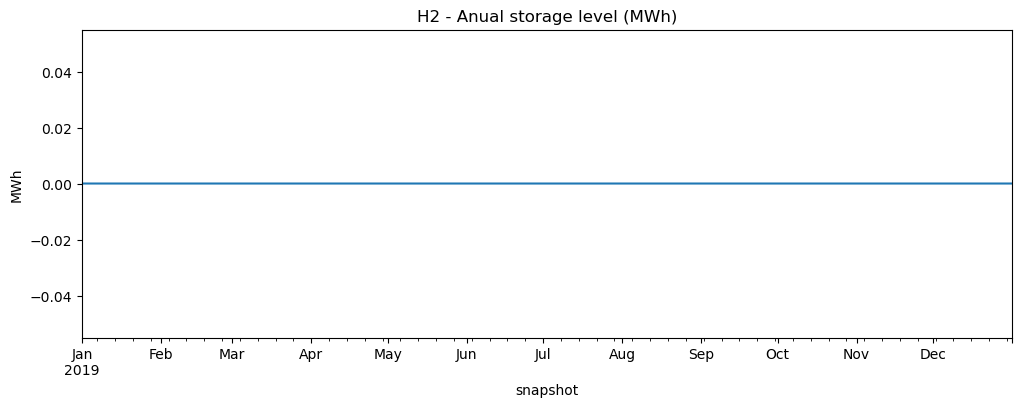

In [9]:

# --- Results: installed capacities ---
print("=== GENERATORS (part c) ===")
print(nf.generators[["p_nom_opt"]])

# --- Results: Annual Generation in TWh ---
print("\n=== ANNUAL GENERATION (part c) [TWh] ===")
# Calculamos en MWh y dividimos por 1,000,000 para obtener TWh
annual_generation_twh = (nf.generators_t.p.multiply(nf.snapshot_weightings.generators, axis=0).sum()) / 1e6
print(annual_generation_twh)

print("\n=== BATTERY ===")
print(nf.storage_units[["p_nom_opt"]])

print("\n=== HYDROGEN - POWER ===")
print(nf.links.loc[["electrolyzer", "fuel_cell"], ["p_nom_opt"]])

print("\n=== HYDROGEN - ENERGY ===")
print(nf.stores[["e_nom_opt"]])

# --- Compare mix from part a vs part c ---
gen_a = n.generators_t.p.sum() / 1e6
gen_c = nf.generators_t.p.sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gen_a.plot.bar(ax=axes[0], title="Part a - Without storage (TWh)")
axes[0].set_ylabel("TWh")
gen_c.plot.bar(ax=axes[1], title="Part c - With storage (TWh)")
axes[1].set_ylabel("TWh")
plt.tight_layout()
plt.show()

# --- Battery stage of charge: winter and summer ---
soc = nf.storage_units_t.state_of_charge

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
soc["battery"].loc["2019-01-14":"2019-01-20"].plot(
    ax=axes[0], title="Battery - State of Charge (Winter)")
axes[0].set_ylabel("MWh")

soc["battery"].loc["2019-07-15":"2019-07-21"].plot(
    ax=axes[1], title="Battery - State of Charge (Summer)")
axes[1].set_ylabel("MWh")
plt.tight_layout()
plt.show()

# --- Anual H2 level ---
fig, ax = plt.subplots(figsize=(12, 4))
nf.stores_t.e["H2_storage"].plot(
    ax=ax, title="H2 - Anual storage level (MWh)")
ax.set_ylabel("MWh")
plt.show()

### TABLE WITH INFORMATION AND RESULTS

In [10]:
# --- Table of Storage Technologies ---
import pandas as pd

# CAPEX brutos DEA 2020

CAPEX_BATTERY_MWh = 183_000        # €/MWh
CAPEX_BATTERY_MW  = 183_000 * 6    # €/MW (×max_hours)
CAPEX_ELECTROLYZER = 840_000       # €/MW
CAPEX_H2_STORAGE   = 6_010        # €/MWh
CAPEX_FUEL_CELL   = 1_591_578    # €/MW

storage_comparison = pd.DataFrame({
    "Li-ion Battery": {
        "Power capacity (MW)":          round(nf.storage_units.loc["battery", "p_nom_opt"], 1),
        "Energy capacity (MWh)":        round(nf.storage_units.loc["battery", "p_nom_opt"] * 6, 1),
        "Charge efficiency (%)":        93.0,
        "Discharge efficiency (%)":     93.0,
        "Round-trip efficiency (%)":    round(0.93 * 0.93 * 100, 1),
        "Max hours (h)":                6,
        "CAPEX (€/MWh) - DEA 2020":    CAPEX_BATTERY_MWh,
        "CAPEX (€/MW)  - DEA 2020":    CAPEX_BATTERY_MW,
        "Annual charge (MWh)":          round(nf.storage_units_t.p.clip(upper=0)["battery"].abs().sum(), 1),
        "Annual discharge (MWh)":       round(nf.storage_units_t.p.clip(lower=0)["battery"].sum(), 1),
        "Time scale":                   "Intraday",
    },
    "Hydrogen (P2G)": {
        "Power capacity (MW)":          round(nf.links.loc["electrolyzer", "p_nom_opt"], 1),
        "Energy capacity (MWh)":        round(nf.stores.loc["H2_storage", "e_nom_opt"], 1),
        "Charge efficiency (%)":        73.0,
        "Discharge efficiency (%)":     58.0,
        "Round-trip efficiency (%)":    round(0.73 * 0.58 * 100, 1),
        "Max hours (h)":                "seasonal",
        "CAPEX (€/MWh) - DEA 2020":    CAPEX_H2_STORAGE,
        "CAPEX (€/MW)  - DEA 2020":    CAPEX_ELECTROLYZER + CAPEX_FUEL_CELL,
        "Annual charge (MWh)":          round(nf.links_t.p0["electrolyzer"].clip(lower=0).sum(), 1),
        "Annual discharge (MWh)":       round(nf.links_t.p0["fuel_cell"].clip(lower=0).sum(), 1),
        "Time scale":                   "Seasonal",
    }
})

print(storage_comparison.to_string())


                          Li-ion Battery Hydrogen (P2G)
Power capacity (MW)               1064.1            0.0
Energy capacity (MWh)             6384.6            0.0
Charge efficiency (%)               93.0           73.0
Discharge efficiency (%)            93.0           58.0
Round-trip efficiency (%)           86.5           42.3
Max hours (h)                          6       seasonal
CAPEX (€/MWh) - DEA 2020          183000           6010
CAPEX (€/MW)  - DEA 2020         1098000        2431578
Annual charge (MWh)             713059.9            0.0
Annual discharge (MWh)          616000.2            0.0
Time scale                      Intraday       Seasonal


### COSTS COMPARISON

Costs part a (without storage) VS. Costs part c (with storage)

In [11]:
print("Coste total parte a:", n.objective)
print("Coste total parte c:", nf.objective)

Coste total parte a: 2863533615.870427
Coste total parte c: 2817013177.1896873


Savings from part a to part c

In [12]:
saving = n.objective - nf.objective
saving_pct = (saving / n.objective) * 100

print(f"Total cost part a: {n.objective/1e9:.3f}*(10**9)USD/year")
print(f"Total cost part c: {nf.objective/1e9:.3f}*(10**9)USD/year")
print(f"Saving:            {saving/1e6:.1f}*(10**6)USD/year ({saving_pct:.1f}%)")


Total cost part a: 2.864*(10**9)USD/year
Total cost part c: 2.817*(10**9)USD/year
Saving:            46.5*(10**6)USD/year (1.6%)


In [13]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [14]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [15]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [16]:
annuity(0.07, 20)

0.09439292574325567

In [17]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

In [18]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [19]:
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [20]:
data_solar = pd.read_csv(f"{DENMARK_PATH}/ninja-pv-country-DK-national-merra2.csv", skiprows=3)

data_windonshore = pd.read_csv(f"{DENMARK_PATH}/ninja-wind-country-DK-current_onshore-merra2.csv", skiprows=3)

data_windoffshore = pd.read_csv(f"{DENMARK_PATH}/ninja-wind-country-DK-current_offshore-merra2.csv", skiprows=3)

data_el = pd.read_csv(LOAD_PATH)

In [21]:

def build_network_with_co2_cap(co2_cap_mt):
      
      nc = pypsa.Network() # thiscreates a new PyPSA network object. This object represents the electricity system that we will analyze.
      nc.set_snapshots(snapshots) #we are setting the time resolution of the model.

      nc.add("Bus", "Denmark") #we are creating the bus, wich in this model represents a node where electricity flows are balanced. 

      nc.add(
      "Load",
      "demand",
      bus="Denmark",
      p_set=data["load"].values
      )# we are adding the electricity demand to the bus. The p_set parameter specifies the time series of electricity demand that we want to meet at each snapshot.

      nc.add(
      "Generator",
      "solar",
      bus="Denmark",
      carrier="solar",
      p_max_pu=data["solar_cf"].values,
      p_nom_extendable=True,
      capital_cost=CAPITAL_COST_SOLAR,
      marginal_cost=MARGINAL_COST_SOLAR
      )

      nc.add(
      "Generator",
      "wind_onshore",
      bus="Denmark",
      carrier="wind_onshore",
      p_max_pu=data["wind_on_cf"].values,
      p_nom_extendable=True,
      capital_cost= CAPITAL_COST_WIND_ON,
      marginal_cost=MARGINAL_COST_WIND_ON
      )

      nc.add(
      "Generator",
      "wind_offshore",
      bus="Denmark",
      carrier="wind_offshore",
      p_max_pu=data["wind_off_cf"].values,
      p_nom_extendable=True,
      capital_cost=CAPITAL_COST_WIND_OFF,
      marginal_cost=MARGINAL_COST_WIND_OFF
      )
      nc.add(
      "Generator",
      "gas",
      bus="Denmark",
      carrier="gas",
      efficiency=0.47,
      p_nom_extendable=True,
      capital_cost=CAPITAL_COST_GAS,
      marginal_cost=MARGINAL_COST_GAS
      )

      nc.add("Carrier", "solar", co2_emissions=0.0)
      nc.add("Carrier", "wind_onshore", co2_emissions=0.0)
      nc.add("Carrier", "wind_offshore", co2_emissions=0.0)
      nc.add("Carrier", "gas", co2_emissions=55 / 1e3)

      nc.add("GlobalConstraint", "co2_cap",
      type="primary_energy",
      carrier_attribute="co2_emissions",
      sense="<=",
      constant=co2_cap_mt)
      
      return nc

In [22]:
print("Promedios de CF:")
print(f"Onshore: {data['wind_on_cf'].mean():.4f}")
print(f"Offshore: {data['wind_off_cf'].mean():.4f}")
print(f"Solar: {data['solar_cf'].mean():.4f}")

Promedios de CF:
Onshore: 0.2745
Offshore: 0.3777
Solar: 0.1135


In [23]:
def solve_with_co2_cap(co2_cap_mt):
    nc = build_network_with_co2_cap(co2_cap_mt)
    nc.optimize(solver_name="gurobi")
    cap = nc.generators["p_nom_opt"].copy()
    gen = nc.generators_t.p.mul(nc.snapshot_weightings.generators, axis=0).sum()
    
    emissions = nc.carriers.co2_emissions @ nc.generators_t.p.mul(nc.snapshot_weightings.generators, axis=0).sum() / 1e6  # MtCO2
    
    return cap, gen, emissions, nc

co2_caps_mt = np.linspace(5e4, 3e6, 20)
results = []

for cap_mt in co2_caps_mt:
    cap, gen, emissions, nc = solve_with_co2_cap(cap_mt)
    shadow_price = nc.global_constraints.loc["co2_cap", "mu"]


    row = {
        "co2_cap_mt": cap_mt,
        "actual_emissions_mt": emissions,
        "shadow_price_co2": shadow_price,
        "objective": nc.objective
    }

    techs = ["solar", "wind_onshore", "wind_offshore", "gas"]
    for tech in techs:
        row[f"gen_{tech}_twh"] = gen[tech] / 1e6
        row[f"cap_{tech}_mw"] = cap[tech]

    results.append(row)

results_df = pd.DataFrame(results)

C:\Users\raula\AppData\Local\Temp\ipykernel_32956\342729396.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  nc.optimize(solver_name="gurobi")
Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 221.12it/s]
INFO:linopy.io: Writing time: 0.08s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2785388


INFO:gurobipy:Set parameter LicenseID to value 2785388


...

INFO:gurobipy:


Solved in 8440 iterations and 0.89 seconds (0.48 work units)


INFO:gurobipy:Solved in 8440 iterations and 0.89 seconds (0.48 work units)


Optimal objective  2.863533616e+09


INFO:gurobipy:Optimal objective  2.863533616e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78845 duals
Objective: 2.86e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


In [24]:
print(nc.carriers)
print(nc.generators[["carrier", "efficiency", "p_nom_extendable"]])
print(nc.global_constraints)

               co2_emissions color nice_name  max_growth  max_relative_growth
name                                                                         
solar                  0.000                         inf                  0.0
wind_onshore           0.000                         inf                  0.0
wind_offshore          0.000                         inf                  0.0
gas                    0.055                         inf                  0.0
                     carrier  efficiency  p_nom_extendable
name                                                      
solar                  solar        1.00              True
wind_onshore    wind_onshore        1.00              True
wind_offshore  wind_offshore        1.00              True
gas                      gas        0.47              True
                   type  investment_period bus carrier_attribute sense  \
name                                                                     
co2_cap  primary_energy       

In [25]:
def audit_network(nc):
    
    

    print("\n1. Carriers :")
    print(nc.generators[['carrier', 'p_nom_extendable']])
    

    print("\n2. Emissions:")
    print(nc.carriers['co2_emissions'])
    

    if "co2_cap" in nc.global_constraints.index:
        constraint = nc.global_constraints.loc["co2_cap"]
        print("\n3. Status of 'co2_cap':")
        print(f"   Cap defined: {constraint['constant']} kgCO2")
        print(f"   Shadow Price (mu): {constraint['mu']} €/kgCO2")
        
        if constraint['mu'] > 0:
            print("   -> ¡CORRECT! La restricción is active")
        else:
            print("   -> ¡WARNING! ")
    else:
        print("\n3. ERROR")


    print("\n4. Generators connected to buses:")
    print(nc.generators['bus'].value_counts())

audit_network(nc)


1. Carriers :
                     carrier  p_nom_extendable
name                                          
solar                  solar              True
wind_onshore    wind_onshore              True
wind_offshore  wind_offshore              True
gas                      gas              True

2. Emissions:
name
solar            0.000
wind_onshore     0.000
wind_offshore    0.000
gas              0.055
Name: co2_emissions, dtype: float64

3. Status of 'co2_cap':
   Cap defined: 3000000.0 kgCO2
   Shadow Price (mu): 0.0 €/kgCO2
   -> ¡WARNING! 

4. Generators connected to buses:
bus
Denmark    4
Name: count, dtype: int64


In [26]:
print(results_df.columns.tolist())

['co2_cap_mt', 'actual_emissions_mt', 'shadow_price_co2', 'objective', 'gen_solar_twh', 'cap_solar_mw', 'gen_wind_onshore_twh', 'cap_wind_onshore_mw', 'gen_wind_offshore_twh', 'cap_wind_offshore_mw', 'gen_gas_twh', 'cap_gas_mw']


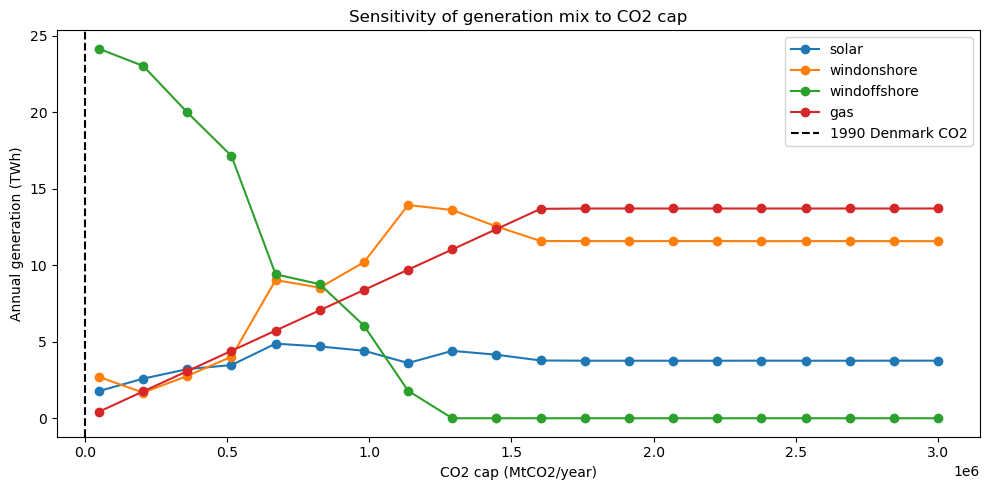

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

tech_map = {
    "solar": "gen_solar_twh",
    "windonshore": "gen_wind_onshore_twh", 
    "windoffshore": "gen_wind_offshore_twh",
    "gas": "gen_gas_twh"
}

for tech_name, col_name in tech_map.items():
    ax.plot(results_df["co2_cap_mt"], results_df[col_name], marker="o", label=tech_name)

ax.axvline(52.887, color="black", linestyle="--", label="1990 Denmark CO2")
ax.set_xlabel("CO2 cap (MtCO2/year)")
ax.set_ylabel("Annual generation (TWh)")
ax.set_title("Sensitivity of generation mix to CO2 cap")
ax.legend()
plt.tight_layout()
plt.show()

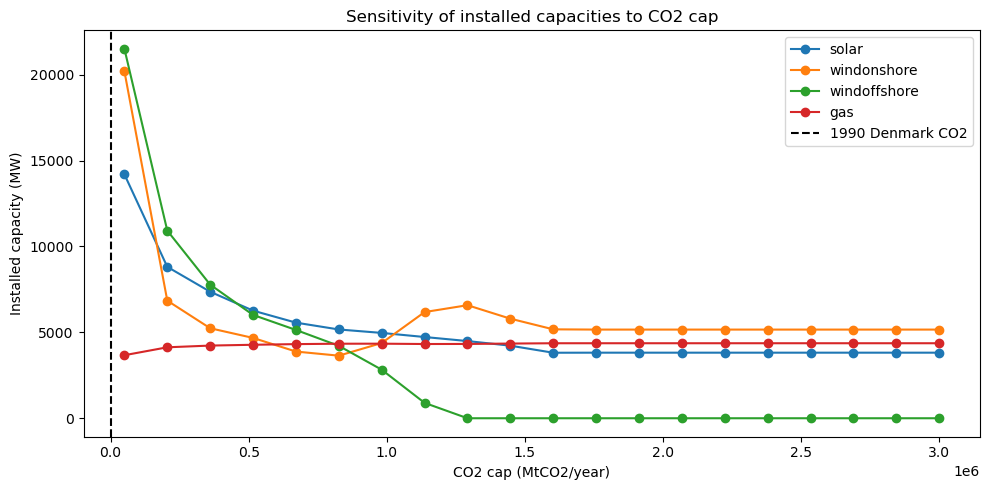

In [28]:
cap_map = {
    "solar": "cap_solar_mw",
    "windonshore": "cap_wind_onshore_mw",
    "windoffshore": "cap_wind_offshore_mw", 
    "gas": "cap_gas_mw"
}

fig, ax = plt.subplots(figsize=(10, 5))
for tech_name, col_name in cap_map.items():
    ax.plot(results_df["co2_cap_mt"], results_df[col_name], marker="o", label=tech_name)

ax.axvline(52.887, color="black", linestyle="--", label="1990 Denmark CO2")
ax.set_xlabel("CO2 cap (MtCO2/year)")
ax.set_ylabel("Installed capacity (MW)")
ax.set_title("Sensitivity of installed capacities to CO2 cap")
ax.legend()
plt.tight_layout()
plt.show()